In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [6]:
# 1. Define paths
train_dir = './raw_data/train'
csv_path = './raw_data/train_labels.csv'

In [7]:
# 2. Load the CSV file
df = pd.read_csv(csv_path)

print("First 5 rows of the dataset:")
print(df.head())
print("-" * 30)

First 5 rows of the dataset:
   image_id     class
0         1    DogEye
1         2  DogMouth
2         3   DogFace
3         4   DogNose
4         5   DogNose
------------------------------


In [12]:
# 3. Count how many images belong to each class
class_counts = df['class'].value_counts() # Change 'label' if your column is named differently

print("--- Dataset Image Counts ---")
print(class_counts)
print("-" * 30)
print(df['class'].dtype)

--- Dataset Image Counts ---
class
CatEye      13884
DogEye      11580
CatNose      6942
CatFace      6942
CatMouth     6942
DogMouth     5790
DogFace      5790
DogNose      5790
Name: count, dtype: int64
------------------------------
str


### Making a copy of with file path

In [23]:
dfCopy = df.copy(deep=True)
dfCopy['image_id'] =  (dfCopy['image_id']).astype(str).str.zfill(5)
dfCopy['file_path'] = dfCopy['image_id'] + '.jpg'
dfCopy.to_csv('./raw_data/train_labels_strId.csv', index=True)

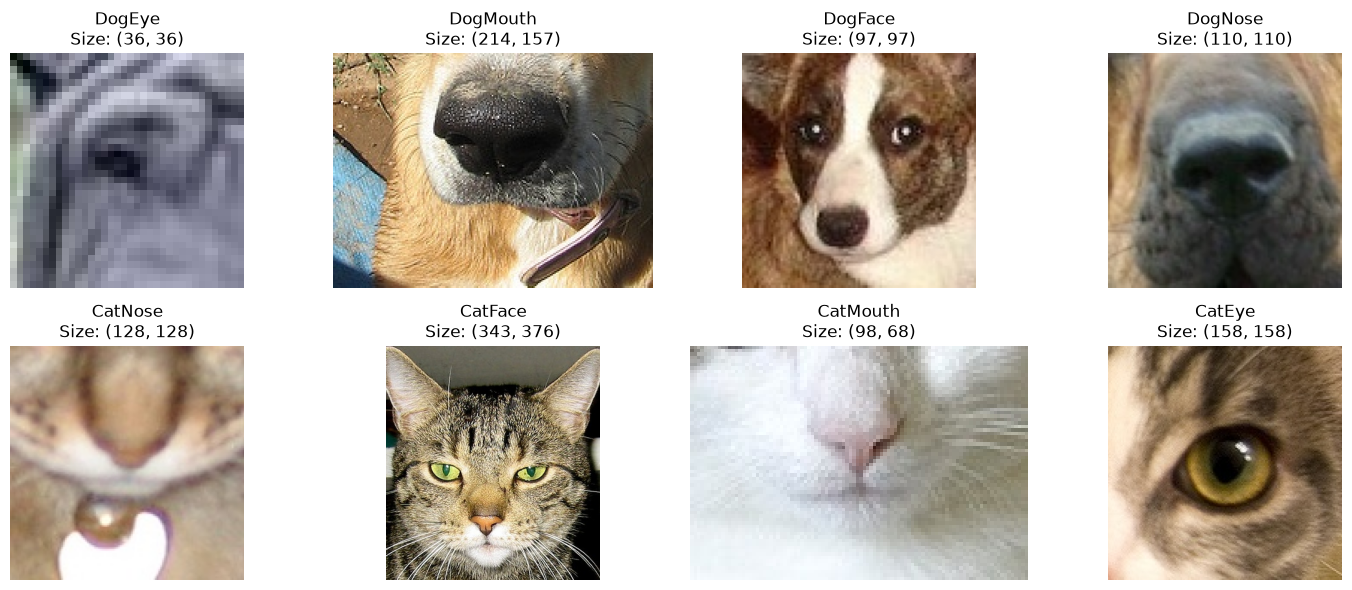

In [33]:
# 4. Visualize one image from each class
plt.figure(figsize=(15, 6))

# Get the unique class names
unique_classes = dfCopy['class'].unique()


for i, class_name in enumerate(unique_classes):
    # Find the first image_id that matches this class
    # Change 'image_id' and 'label' if your CSV columns are named differently
    sample_image_name = dfCopy[dfCopy['class'] == class_name]['file_path'].iloc[0]
    
    # Construct the full path to the image
    # print(sample_image_name)
    img_path = os.path.join(train_dir, sample_image_name).replace('\\', '/')
    # print(img_path)
    
    # # Open and plot
    img = Image.open(img_path)
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(f"{class_name}\nSize: {img.size}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### Resizing and Some what cleaning the images

In [41]:
from datacleaner import build_training_dataloaders

In [71]:
# 1. Load the data using our custom package
train_loader, val_loader = build_training_dataloaders(
    csv_path='./raw_data/train_labels_strid.csv', 
    img_dir='./raw_data/train', 
    batch_size=32
)

# 2. Verify it imported and ran correctly
print(len(train_loader))
for images, labels in train_loader:
    print("\nData loaded successfully via data_utils.py!")
    print("Batch shape:", images.shape)
    break

1592

Data loaded successfully via data_utils.py!
Batch shape: torch.Size([32, 3, 224, 224])


### Seeing what changed in the image

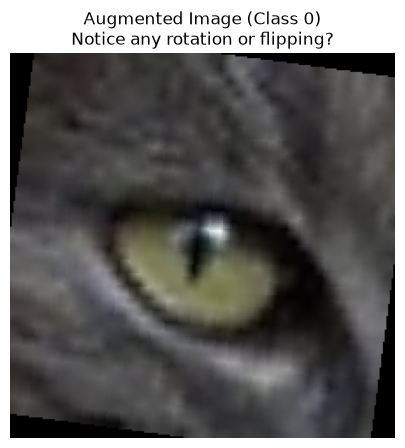

In [60]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Grab exactly one batch of images and labels from our train_loader
images, labels = next(iter(train_loader))

# 2. Pick the very first image in that batch (index 0)
img_tensor = images[0]
label_idx = labels[0].item() # .item() converts it from a PyTorch tensor to a standard Python integer

# 3. Denormalize the image (Reverse the math)
# PyTorch tensors are (ColorChannels, Height, Width). We move channels to the end for Matplotlib.
# changing / transposing the tensor
img_numpy = img_tensor.permute(1, 2, 0).numpy()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# Formula: original = (normalized * std) + mean
denormalized_img = (img_numpy * std) + mean

# Ensure values don't slightly exceed 0.0 or 1.0 due to float rounding
denormalized_img = np.clip(denormalized_img, 0, 1)

# 4. Plot it!
plt.figure(figsize=(5, 5))
plt.imshow(denormalized_img)

# We can find the original string name by reversing our dictionary (optional, just for display)
# We know the dataset has 8 classes, so 0-7 correspond to alphabetical class names.
plt.title(f"Augmented Image (Class {label_idx})\nNotice any rotation or flipping?")
plt.axis('off')
plt.show()